In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import time
import os
import logging
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [ ]:
data_f= './data'
batch_size = 95
learning_rate = 0.001
epochs = 15
num_classes = 10

device = torch.device('cpu')

In [ ]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),  
    transforms.RandomRotation(25),  
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2)),  
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


2025-12-01 02:03:18,186 - INFO - 1) Loading data
2025-12-01 02:03:19,492 - INFO - Data loaded: 50000 training, 10000 test samples


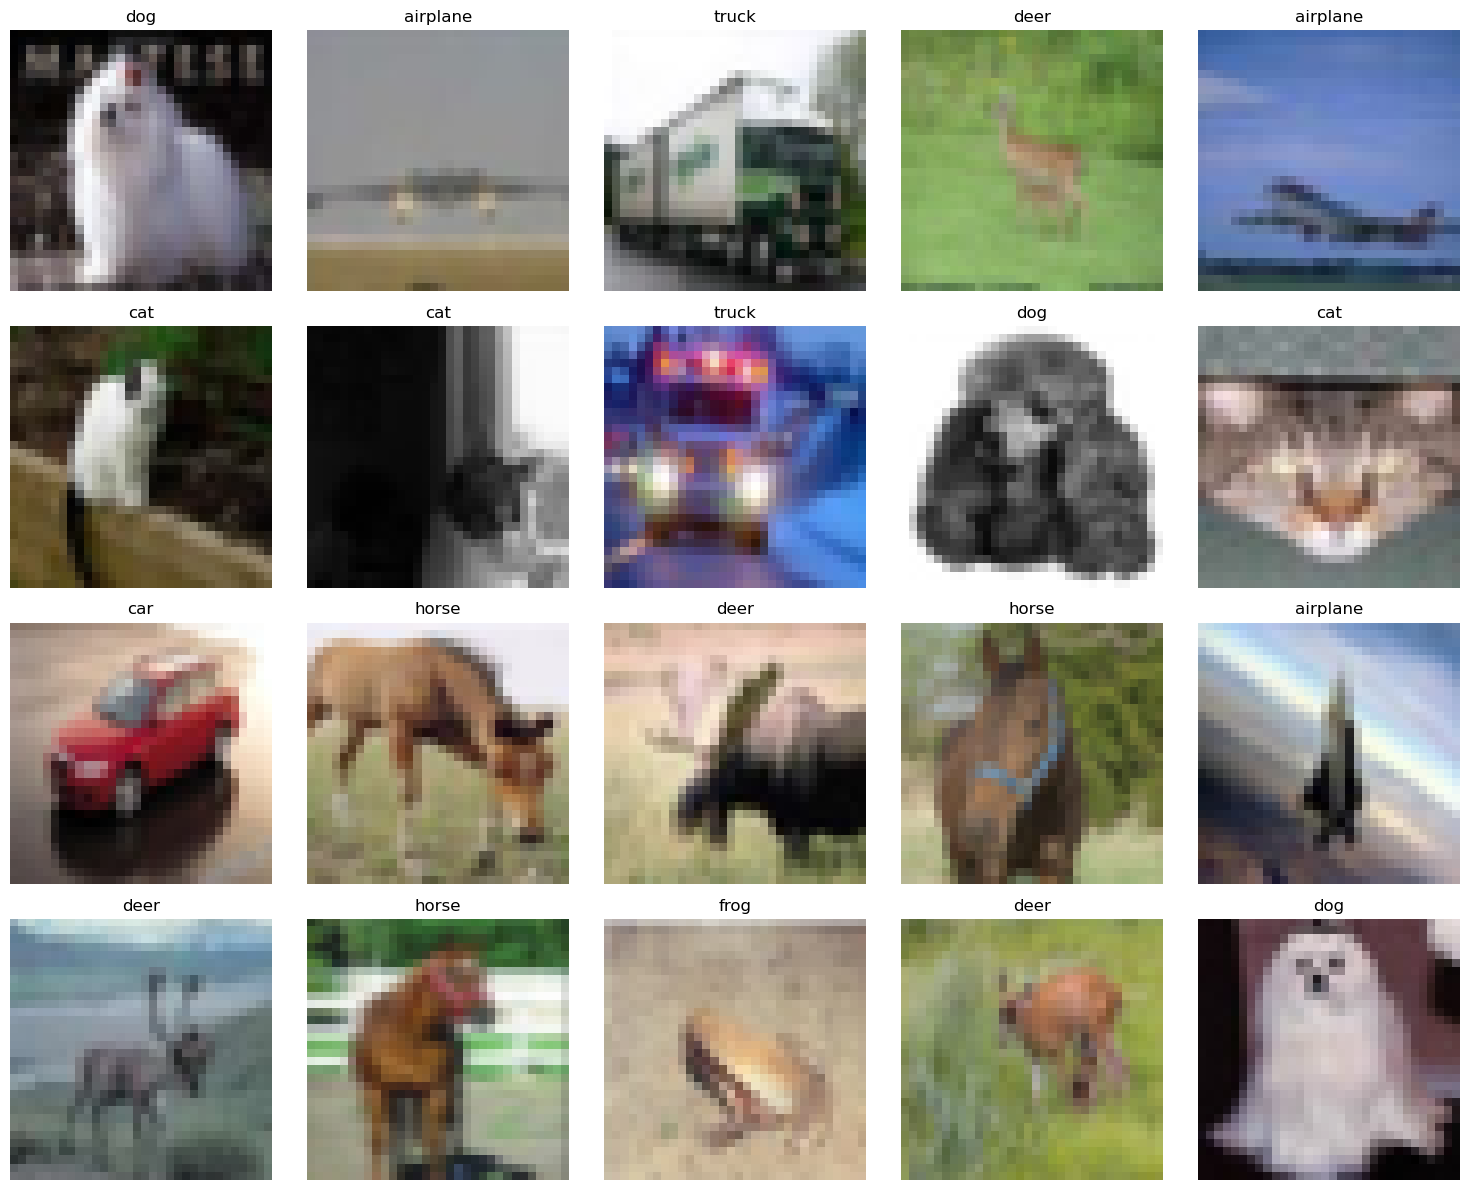

In [ ]:
logging.info("1) Loading data")

def show_images(images, labels, num_images = 20):
    classes = ["airplane", "car", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
    cols = 5
    rows = (num_images + cols - 1)// cols
    plt.figure(figsize=(15, 3 * rows))
    for i in range(num_images):
        plt.subplot(rows, 5, i+1)
        img = images[i] / 2 + 0.5   
        img = img.permute(1, 2, 0)  
        plt.imshow(img)
        plt.title(classes[labels[i]])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root= data_f, train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root= data_f, train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

logging.info(f"Data loaded: {len(train_dataset)} training, {len(test_dataset)} test samples")

dataiter = iter(train_loader)
images, labels = next(dataiter)
show_images(images, labels, num_images=20)

In [242]:
logging.info("2) CNN Architecture")

class ConvolutionalNeuralNetwork(nn.Module):
    def __init__(self):
        super(ConvolutionalNeuralNetwork, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.9)
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, num_classes)
    
    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = torch.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = x.view(-1, 128 * 4 * 4)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = ConvolutionalNeuralNetwork().to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

2025-12-02 00:36:56,178 - INFO - 2) CNN Architecture


In [ ]:
def compute_accuracy(loader, model, device):
    correct = 0
    total = 0
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

def plot_training_curves(train_losses, train_accuracies, test_accuracies):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.plot(train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training Loss Over Time')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(train_accuracies, 'g-', label='Train Accuracy', linewidth=2)
    ax2.plot(test_accuracies, 'r-', label='Test Accuracy', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training and Test Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig

In [ ]:
logging.info("3) Training Model")

logging.info("Training Parameters:")
logging.info(f"- Loss function: CrossEntropyLoss")
logging.info(f"- Optimizer: Adam")
logging.info(f"- Learning rate: {learning_rate}")
logging.info(f"- Epochs: {epochs}")
logging.info(f"- Batch size: {batch_size}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-3)  # было 1e-4 → 1e-3

train_losses = []
train_accuracies = []
test_accuracies = []

logging.info("Starting training")
start_time = time.time()

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    epoch_start_time = time.time()
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(train_loader)
    train_accuracy = compute_accuracy(train_loader, model, device)
    test_accuracy = compute_accuracy(test_loader, model, device)
    
    train_losses.append(epoch_loss)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)
    
    epoch_time = time.time() - epoch_start_time
    
    logging.info(f'Epoch [{epoch+1}/{epochs}] completed in {epoch_time:.2f}s:')
    logging.info(f'Average Loss: {epoch_loss:.4f}')
    logging.info(f'Train Accuracy: {train_accuracy:.2f}%')
    logging.info(f'Test Accuracy: {test_accuracy:.2f}%')

    if epoch > 0:
        loss_improvement = train_losses[-2] - epoch_loss
        logging.info(f'Loss Improvement: {loss_improvement:.4f}')
    else:
        logging.info('Initial Loss')

total_training_time = time.time() - start_time
logging.info(f"Training completed in {total_training_time:.2f} seconds ({total_training_time/60:.2f} minutes)")

2025-12-01 02:03:31,258 - INFO - 3) Training Model
2025-12-01 02:03:31,259 - INFO - Training Parameters:
2025-12-01 02:03:31,259 - INFO - - Loss function: CrossEntropyLoss
2025-12-01 02:03:31,260 - INFO - - Optimizer: Adam
2025-12-01 02:03:31,260 - INFO - - Learning rate: 0.001
2025-12-01 02:03:31,261 - INFO - - Epochs: 15
2025-12-01 02:03:31,261 - INFO - - Batch size: 95
2025-12-01 02:03:31,268 - INFO - Starting training
2025-12-01 02:04:36,426 - INFO - Epoch [1/15] completed in 65.16s:
2025-12-01 02:04:36,427 - INFO - Average Loss: 1.9261
2025-12-01 02:04:36,428 - INFO - Train Accuracy: 43.69%
2025-12-01 02:04:36,428 - INFO - Test Accuracy: 43.39%
2025-12-01 02:04:36,429 - INFO - Initial Loss
2025-12-01 02:05:41,246 - INFO - Epoch [2/15] completed in 64.82s:
2025-12-01 02:05:41,246 - INFO - Average Loss: 1.6842
2025-12-01 02:05:41,247 - INFO - Train Accuracy: 49.60%
2025-12-01 02:05:41,247 - INFO - Test Accuracy: 49.10%
2025-12-01 02:05:41,248 - INFO - Loss Improvement: 0.2419
2025-1

2025-12-01 02:20:37,382 - INFO - Plotting training curves


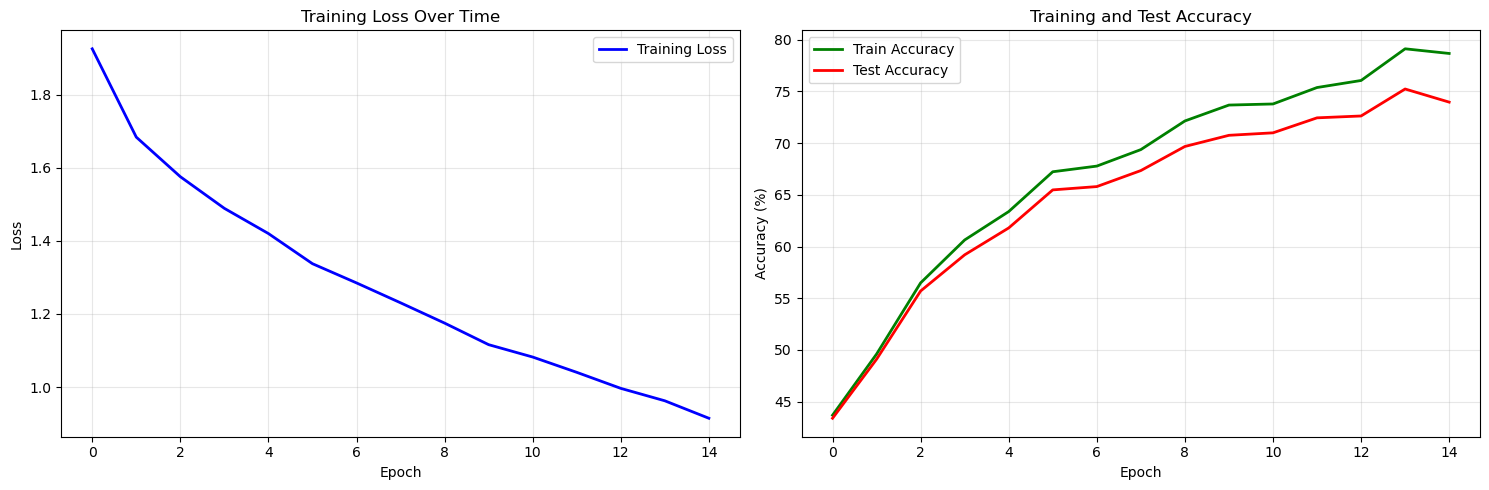

2025-12-01 02:20:37,609 - INFO - Final Results:
2025-12-01 02:20:37,610 - INFO - Final Train Accuracy: 78.68%
2025-12-01 02:20:37,610 - INFO - Final Test Accuracy: 73.97%
2025-12-01 02:20:37,610 - INFO - Accuracy Gap:  4.71%
2025-12-01 02:20:37,611 - INFO - Best Test Accuracy: 75.24%


In [ ]:
logging.info("Plotting training curves")

fig = plot_training_curves(train_losses, train_accuracies, test_accuracies)

final_train_accuracy = train_accuracies[-1]
final_test_accuracy = test_accuracies[-1]
accuracy_gap = final_train_accuracy - final_test_accuracy

logging.info("Final Results:")
logging.info(f"Final Train Accuracy: {final_train_accuracy:.2f}%")
logging.info(f"Final Test Accuracy: {final_test_accuracy:.2f}%")
logging.info(f"Accuracy Gap: {accuracy_gap: .2f}%")
logging.info(f"Best Test Accuracy: {max(test_accuracies):.2f}%")

In [ ]:
logging.info("4) Testing Model")

test_start_time = time.time()

final_test_accuracy = compute_accuracy(test_loader, model, device)
test_time = time.time() - test_start_time

avg_time_per_image = (test_time / len(test_dataset)) * 1000  

logging.info("Testing Results:")
logging.info(f"Final Test Accuracy: {final_test_accuracy:.2f}%")
logging.info(f"Testing Time: {test_time:.2f} seconds")
logging.info(f"Average Time per Image: {avg_time_per_image:.4f} ms")
logging.info(f"Images Processed per Second: {len(test_dataset) / test_time:.2f}")

2025-11-30 01:47:31,993 - INFO - 4) Testing Model
2025-11-30 01:47:37,314 - INFO - Testing Results:
2025-11-30 01:47:37,314 - INFO - Final Test Accuracy: 68.18%
2025-11-30 01:47:37,315 - INFO - Testing Time: 5.32 seconds
2025-11-30 01:47:37,316 - INFO - Average Time per Image: 0.5320 ms
2025-11-30 01:47:37,316 - INFO - Images Processed per Second: 1879.65


In [ ]:
logging.info("5) Final Results")

torch.save(model.state_dict(), 'cifar10_cnn_model.pth')
logging.info("Model saved as 'cifar10_cnn_model.pth'")

logging.info(f"Training time: {total_training_time:.2f}s")
logging.info(f"Final training accuracy: {train_accuracies[-1]:.2f}%")
logging.info(f"Final test accuracy: {final_test_accuracy:.2f}%")
logging.info(f"Overfitting gap: {train_accuracies[-1] - final_test_accuracy:.2f}%")
logging.info(f"Best test accuracy: {max(test_accuracies):.2f}%")

print(f"Final Test Accuracy: {final_test_accuracy:.2f}%")
print(f"Total Training Time: {total_training_time:.2f} seconds")

2025-11-30 01:47:42,636 - INFO - 5) Final Results
2025-11-30 01:47:42,653 - INFO - Model saved as 'cifar10_cnn_model.pth'
2025-11-30 01:47:42,654 - INFO - Training time: 1515.32s
2025-11-30 01:47:42,654 - INFO - Final training accuracy: 71.20%
2025-11-30 01:47:42,655 - INFO - Final test accuracy: 68.18%
2025-11-30 01:47:42,655 - INFO - Overfitting gap: 3.02%
2025-11-30 01:47:42,655 - INFO - Best test accuracy: 68.18%


Final Test Accuracy: 68.18%
Total Training Time: 1515.32 seconds
